In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

In [7]:
# Carrega os dados
fashion_mnist = tf.keras.datasets.fashion_mnist

# Divide os dados para treino/teste
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
# Normaliza os dados de treino
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x-train.shape:", x_train.shape)

x-train.shape: (60000, 28, 28)


In [8]:
# A convolução espera dados 3D (altura, largura e cor)
# Então, adicionar mais uma dimensão
x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)
print(x_train.shape)

(60000, 28, 28, 1)


In [9]:
# Vê a quantidade de classes
K = len(set(y_train))
print("Quantidade de Classes: ", K)

Quantidade de Classes:  10


In [11]:
# Contruindo o modelo
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i)
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)

In [12]:
# Compila e treina o modelo
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8080 - loss: 0.5167 - val_accuracy: 0.8508 - val_loss: 0.4108
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8655 - loss: 0.3582 - val_accuracy: 0.8643 - val_loss: 0.3714
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.8833 - loss: 0.3084 - val_accuracy: 0.8794 - val_loss: 0.3214
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.8952 - loss: 0.2773 - val_accuracy: 0.8912 - val_loss: 0.2992
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9058 - loss: 0.2489 - val_accuracy: 0.8896 - val_loss: 0.3086
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9150 - loss: 0.2280 - val_accuracy: 0.8935 - val_loss: 0.2960
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9218 - loss: 0.2069 - val_accuracy: 0.9000 - val_loss: 0.3095
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.9275 -

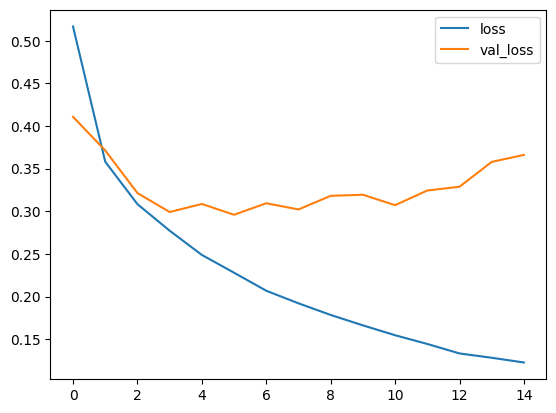

In [13]:
import matplotlib.pyplot as plt
# PLota uma periodização
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

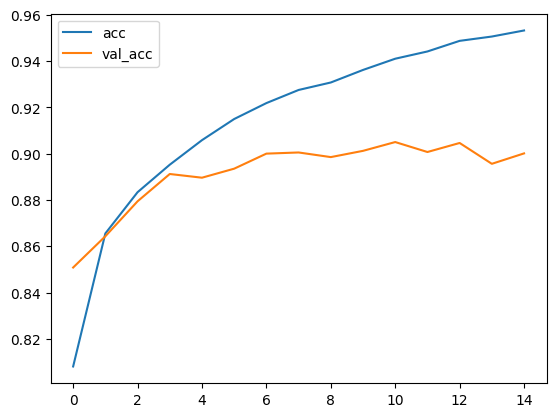

In [14]:
# Plota a precisão por iteração
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Matrix de Confusão sem normalizar
[[876   3  24  16   4   1  72   0   4   0]
 [  1 983   1  11   3   0   0   0   1   0]
 [ 16   1 869  10  41   1  61   0   1   0]
 [ 21   9  17 903  24   1  24   0   1   0]
 [  2   2  68  28 836   0  62   0   2   0]
 [  1   0   0   0   0 967   0  18   0  14]
 [130   0  65  32  89   1 668   0  15   0]
 [  0   0   0   0   0  10   0 982   0   8]
 [  1   1   7   2   2   4   5   3 974   1]
 [  0   0   0   0   0   5   1  51   0 943]]


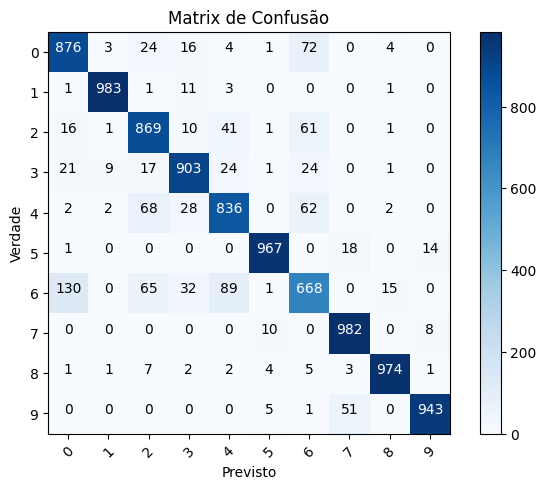

In [17]:
# Plota a matrix de confusão
from sklearn.metrics import confusion_matrix
import itertools

# Função pra plotar a matrix de confusão
def plot_confusion_matrix(
    cm,
    classes,
    normalize=False,
    title='Matrix de Confusão',
    cmap=plt.cm.Blues):
    # Se normalize for verdadeiro
    if normalize:
        # Normaliza a matrix
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Matrix de Confusão Normalizada')
    else:
        print('Matrix de Confusão sem normalizar')

    # Printa a matrix
    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    # Legenda do eixo x e y
    plt.ylabel('Verdade')
    plt.xlabel('Previsto')
    # Mostra a Matrix
    plt.show()

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [18]:
# Mapeando os labels
labels = '''T-shirt/top
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot'''.split() # Separa eles

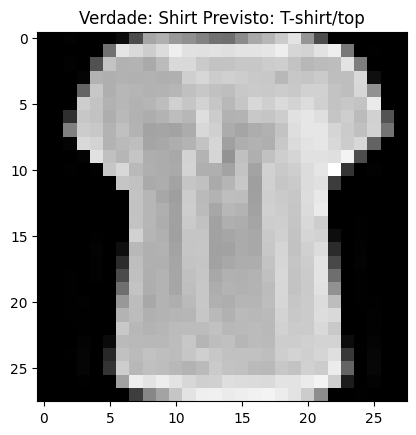

In [40]:
misclassified_idx = np.where(p_test != y_test)[0]
i = np.random.choice(misclassified_idx)
plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
plt.title('Verdade: %s Previsto: %s' % (labels[y_test[i]], labels[p_test[i]]));